In [1]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl
!pip install selenium webdriver-manager
!pip install fiona

!pip install netCDF4
!pip install seaborn
!pip install scipy
!pip install pygam
!pip install mplcursors


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Cruise Samples
Trying to get the matlab overall Rrs to site by site Rrs

In [2]:

import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib
import mplcursors
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import FixedLocator
from matplotlib.lines import Line2D
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
from shapely import wkb
import pandas as pd
import re
import time
import json
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from scipy import stats
from statsmodels.tsa.seasonal import STL
import geopandas as gpd
import rioxarray
import fiona
from pygam import LinearGAM, s, f
import numpy as np

In [3]:
file_path = "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260428/Matlab/InstrumentData/260428/260428PAR/20260428_Es_Irradiance_PhotonFlux.dat"


In [4]:
# Read only the first 50 lines to inspect the header
with open(file_path, 'r') as f:
    for i in range(50):
        print(f"Line {i+1}: {f.readline().strip()}")

Line 1: #Radiometer: SAM_82C1
Line 2: #Parameter: Irradiance (Es)
Line 3: #Unit: mW m-2
Line 4: #
Line 5: #Celtic Explorer
Line 6: #Measurement method: Radiometer (RAMSES, TriOS GmbH, Germany
Line 7: #Azimuth=40Â°
Line 8: #Nadir=40Â°
Line 9: #SetupHeight=1 m
Line 10: #Latitude=53 45 00.94095 Â°N
Line 11: #Longitude=7 40 16.00638 Â°E
Line 12: #Research project: Surface Reflectance Galway Bay 2026
Line 13: #Contact: University of Oldenburg, ICBM, Working group Marine Sensor Systems (Oliver Zielinski)
Line 14: #E-mail: peter.croot@nuigalway.ie; jochen.wollschlaeger@uol.de
Line 15: #
Line 16: #Instrument initialization file: SAM_82C1.ini; 2015-02-17 12:15:55
Line 17: #c0: 299.093
Line 18: #c1: 3.306
Line 19: #c2: 0.00037601
Line 20: #c3: -1.8194e-06
Line 21: #DarkPixelStart: 237
Line 22: #DarkPixelStop: 254
Line 23: #
Line 24: #Background file: DLAB_2015-02-12_12-33-23_994_457; 2015-02-12 12:33:23
Line 25: #Background spectrum: 0.017166 0.016904 0.017050 0.017025 0.017119 0.016960 0.017061

In [5]:

try:
    # Assuming data is in a structured format like CSV or similar
    df = pd.read_csv(file_path, delimiter='\t', skiprows=39)
    # Process the DataFrame
    print(df)

except FileNotFoundError:
    print(f"File '{file_path}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

      Year  Month  Day  Hour  Minute  Second  \
0     2026      4   28    11      23       4   
1     2026      4   28    11      23       6   
2     2026      4   28    11      23       8   
3     2026      4   28    11      23      11   
4     2026      4   28    11      23      14   
...    ...    ...  ...   ...     ...     ...   
5405  2026      4   28    16      48      40   
5406  2026      4   28    16      48      42   
5407  2026      4   28    16      48      44   
5408  2026      4   28    16      48      46   
5409  2026      4   28    16      48      48   

      Photon Flux (PAR) [µmol photons m-2]  \
0                               694.507520   
1                               660.507056   
2                               669.132978   
3                               670.112116   
4                               668.702740   
...                                    ...   
5405                            650.913363   
5406                            652.038284   
5407     

In [6]:
df

,Year,Month,Day,Hour,Minute,Second,Photon Flux (PAR) [µmol photons m-2],Photon Flux (Total) [µmol photons m-2],Irradiance (PAR) [W m-2],Irradiance (Total) [W m-2]
0,2026,4,28,11,23,4,694.507520,1265.587679,151.829725,244.669866
1,2026,4,28,11,23,6,660.507056,1202.114785,144.456037,232.637040
2,2026,4,28,11,23,8,669.132978,1218.437969,146.326896,235.723335
3,2026,4,28,11,23,11,670.112116,1220.032580,146.537362,236.033230
4,2026,4,28,11,23,14,668.702740,1217.738549,146.229850,235.579335
...,...,...,...,...,...,...,...,...,...,...
5405,2026,4,28,16,48,40,650.913363,1201.276800,141.961766,230.518766
5406,2026,4,28,16,48,42,652.038284,1203.452717,142.202269,230.922454
5407,2026,4,28,16,48,44,662.179021,1222.554972,144.393657,234.518003
5408,2026,4,28,16,48,46,652.221460,1203.993695,142.236860,231.004483


I don't think that ^ was what I wanted

In [7]:
file_path = "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260428/Matlab/InstrumentData/260428/260428workingfile/20260428_Rrs.dat"

# Read only the first 50 lines to inspect the header
with open(file_path, 'r') as f:
    for i in range(50):
        print(f"Line {i + 1}: {f.readline().strip()}")

Line 1: #Parameter: Rrs
Line 2: #Irradiance sensor (Es): SAM_82C1
Line 3: #Upward radiance sensor (Lsky): SAM_82CD
Line 4: #Downward eadiance sensor (Lsfc): SAM_82CF
Line 5: #Unit: sr-1
Line 6: #Rrs is corrected for sunglint by subtracting the minimum at 700-900 nm.
Line 7: #However, the sunglint flags were determined by the original spectrum.
Line 8: #To get the original spectrum, just add the minRrs value to the spectrum.
Line 9: #
Line 10: #Celtic Explorer
Line 11: #Measurement method: Radiometer (RAMSES, TriOS GmbH, Germany
Line 12: #Azimuth=40Â°
Line 13: #Nadir=40Â°
Line 14: #SetupHeight=1 m
Line 15: #Latitude=53 45 00.94095 Â°N
Line 16: #Longitude=7 40 16.00638 Â°E
Line 17: #Research project: Surface Reflectance Galway Bay 2026
Line 18: #Contact: University of Oldenburg, ICBM, Working group Marine Sensor Systems (Oliver Zielinski)
Line 19: #E-mail: peter.croot@nuigalway.ie; jochen.wollschlaeger@uol.de
Line 20: #
Line 21: #Correction procedures: Irradiance (Es) has been corrected 

In [8]:

try:
    # Assuming data is in a structured format like CSV or similar
    df_260428 = pd.read_csv(file_path, delimiter='\t', skiprows=49)
    # Process the DataFrame
    print(df)

except FileNotFoundError:
    print(f"File '{file_path}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")
df_260428

      Year  Month  Day  Hour  Minute  Second  \
0     2026      4   28    11      23       4   
1     2026      4   28    11      23       6   
2     2026      4   28    11      23       8   
3     2026      4   28    11      23      11   
4     2026      4   28    11      23      14   
...    ...    ...  ...   ...     ...     ...   
5405  2026      4   28    16      48      40   
5406  2026      4   28    16      48      42   
5407  2026      4   28    16      48      44   
5408  2026      4   28    16      48      46   
5409  2026      4   28    16      48      48   

      Photon Flux (PAR) [µmol photons m-2]  \
0                               694.507520   
1                               660.507056   
2                               669.132978   
3                               670.112116   
4                               668.702740   
...                                    ...   
5405                            650.913363   
5406                            652.038284   
5407     

,Year,Month,Day,Hour,Minute,Second,Flag Light Availability,Flag Light Quality,Flag Weather,Flag Sunglint (Lw),...,932,934,936,938,940,942,944,946,948,950
0,2026,4,28,11,23,7,1,1,1,1,...,0.000241,0.000288,0.000328,0.000354,0.000367,0.000369,0.000365,0.000365,0.000365,0.000365
1,2026,4,28,11,23,11,1,1,1,1,...,0.000202,0.000246,0.000274,0.000286,0.000294,0.000303,0.000306,0.000308,0.000309,0.000308
2,2026,4,28,11,23,14,1,1,1,1,...,0.000209,0.000261,0.000312,0.000349,0.000366,0.000366,0.000362,0.000357,0.000351,0.000345
3,2026,4,28,11,23,17,1,1,1,1,...,0.000221,0.000277,0.000320,0.000341,0.000343,0.000338,0.000338,0.000339,0.000341,0.000342
4,2026,4,28,11,23,20,1,1,1,1,...,0.000228,0.000280,0.000318,0.000340,0.000353,0.000361,0.000359,0.000355,0.000349,0.000341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3455,2026,4,28,16,48,38,1,1,1,1,...,0.000026,0.000040,0.000049,0.000054,0.000053,0.000051,0.000051,0.000051,0.000052,0.000053
3456,2026,4,28,16,48,41,1,1,1,1,...,0.000027,0.000041,0.000056,0.000071,0.000081,0.000083,0.000084,0.000084,0.000084,0.000083
3457,2026,4,28,16,48,44,1,1,1,1,...,-0.000018,-0.000007,0.000014,0.000035,0.000044,0.000043,0.000032,0.000022,0.000011,-0.000001
3458,2026,4,28,16,48,48,1,1,1,1,...,0.000023,0.000034,0.000050,0.000067,0.000081,0.000091,0.000092,0.000090,0.000086,0.000079


KeyError: "['443', '665', '681', '709'] not in index"

 Need to interpolate to get these values for the satellite validation

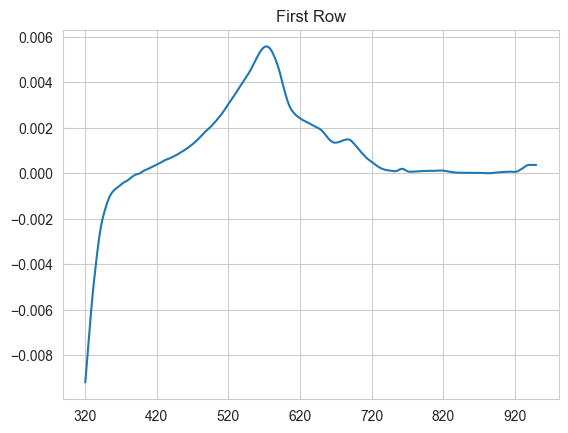

In [9]:
df_260428.iloc[0,12:].plot()
plt.title('First Row')
plt.show()

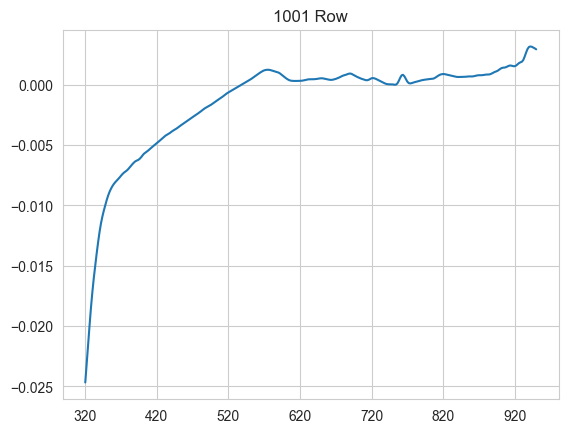

In [10]:
df_260428.iloc[1000,12:].plot()
plt.title('1001 Row')
plt.show()

In [11]:
[int(x) for x in df_260428.columns.to_list()[12:]]

[320,
 322,
 324,
 326,
 328,
 330,
 332,
 334,
 336,
 338,
 340,
 342,
 344,
 346,
 348,
 350,
 352,
 354,
 356,
 358,
 360,
 362,
 364,
 366,
 368,
 370,
 372,
 374,
 376,
 378,
 380,
 382,
 384,
 386,
 388,
 390,
 392,
 394,
 396,
 398,
 400,
 402,
 404,
 406,
 408,
 410,
 412,
 414,
 416,
 418,
 420,
 422,
 424,
 426,
 428,
 430,
 432,
 434,
 436,
 438,
 440,
 442,
 444,
 446,
 448,
 450,
 452,
 454,
 456,
 458,
 460,
 462,
 464,
 466,
 468,
 470,
 472,
 474,
 476,
 478,
 480,
 482,
 484,
 486,
 488,
 490,
 492,
 494,
 496,
 498,
 500,
 502,
 504,
 506,
 508,
 510,
 512,
 514,
 516,
 518,
 520,
 522,
 524,
 526,
 528,
 530,
 532,
 534,
 536,
 538,
 540,
 542,
 544,
 546,
 548,
 550,
 552,
 554,
 556,
 558,
 560,
 562,
 564,
 566,
 568,
 570,
 572,
 574,
 576,
 578,
 580,
 582,
 584,
 586,
 588,
 590,
 592,
 594,
 596,
 598,
 600,
 602,
 604,
 606,
 608,
 610,
 612,
 614,
 616,
 618,
 620,
 622,
 624,
 626,
 628,
 630,
 632,
 634,
 636,
 638,
 640,
 642,
 644,
 646,
 648,
 650,
 652

## Interpolation

In [12]:
## Interpolation
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
# 1. Your confirmed wavelength array
measured_wavelengths = np.array([
    320, 322, 324, 326, 328, 330, 332, 334, 336, 338, 340, 342, 344, 346, 348, 350,
    352, 354, 356, 358, 360, 362, 364, 366, 368, 370, 372, 374, 376, 378, 380, 382,
    384, 386, 388, 390, 392, 394, 396, 398, 400, 402, 404, 406, 408, 410, 412, 414,
    416, 418, 420, 422, 424, 426, 428, 430, 432, 434, 436, 438, 440, 442, 444, 446,
    448, 450, 452, 454, 456, 458, 460, 462, 464, 466, 468, 470, 472, 474, 476, 478,
    480, 482, 484, 486, 488, 490, 492, 494, 496, 498, 500, 502, 504, 506, 508, 510,
    512, 514, 516, 518, 520, 522, 524, 526, 528, 530, 532, 534, 536, 538, 540, 542,
    544, 546, 548, 550, 552, 554, 556, 558, 560, 562, 564, 566, 568, 570, 572, 574,
    576, 578, 580, 582, 584, 586, 588, 590, 592, 594, 596, 598, 600, 602, 604, 606,
    608, 610, 612, 614, 616, 618, 620, 622, 624, 626, 628, 630, 632, 634, 636, 638,
    640, 642, 644, 646, 648, 650, 652, 654, 656, 658, 660, 662, 664, 666, 668, 670,
    672, 674, 676, 678, 680, 682, 684, 686, 688, 690, 692, 694, 696, 698, 700, 702,
    704, 706, 708, 710, 712, 714, 716, 718, 720, 722, 724, 726, 728, 730, 732, 734,
    736, 738, 740, 742, 744, 746, 748, 750, 752, 754, 756, 758, 760, 762, 764, 766,
    768, 770, 772, 774, 776, 778, 780, 782, 784, 786, 788, 790, 792, 794, 796, 798,
    800, 802, 804, 806, 808, 810, 812, 814, 816, 818, 820, 822, 824, 826, 828, 830,
    832, 834, 836, 838, 840, 842, 844, 846, 848, 850, 852, 854, 856, 858, 860, 862,
    864, 866, 868, 870, 872, 874, 876, 878, 880, 882, 884, 886, 888, 890, 892, 894,
    896, 898, 900, 902, 904, 906, 908, 910, 912, 914, 916, 918, 920, 922, 924, 926,
    928, 930, 932, 934, 936, 938, 940, 942, 944, 946, 948, 950
])

# 2. Suppose you want to interpolate for satellite bands: 443, 490, 560, 665
satellite_bands = [443, 665, 681, 709]
# 1. Ensure we are working on a copy
df_final = df_260428.copy()

# 2. Extract the bands
# We use the previous logic to get the Series of 443, 665, 681, 709
num_spectral_points = len(measured_wavelengths)

def extract_satellite_bands(row):
    spectrum = row.iloc[12 : 12 + num_spectral_points].values
    if not np.all(np.isfinite(spectrum)):
        # Create a series to easily use interpolate()
        temp_series = pd.Series(spectrum)
        # 'linear' fill handles small gaps well
        spectrum = temp_series.interpolate(method='linear', limit_direction='both').fillna(0).values

    # 3. Proceed with PCHIP
    f = PchipInterpolator(measured_wavelengths, spectrum)
    return pd.Series(f(satellite_bands), index=satellite_bands)

# Calculate new columns (this creates a DataFrame with columns [443, 665, 681, 709])
new_bands = df_final.apply(extract_satellite_bands, axis=1)

# 3. Add them to the copy
df_final = pd.concat([df_final, new_bands], axis=1)

# 4. Sort columns numerically
# Separate the metadata columns (the first 11) from the data columns
metadata_cols = list(df_final.columns[:12])
data_cols = [c for c in df_final.columns if c not in metadata_cols]

# Sort the data columns numerically
data_cols_sorted = sorted(data_cols, key=lambda x: int(x))

# Final reordering
int_260428 = df_final[metadata_cols + data_cols_sorted]


print(int_260428.head())

   Year  Month  Day  Hour  Minute  Second  Flag Light Availability  \
0  2026      4   28    11      23       7                        1   
1  2026      4   28    11      23      11                        1   
2  2026      4   28    11      23      14                        1   
3  2026      4   28    11      23      17                        1   
4  2026      4   28    11      23      20                        1   

   Flag Light Quality  Flag Weather  Flag Sunglint (Lw)  ...       932  \
0                   1             1                   1  ...  0.000241   
1                   1             1                   1  ...  0.000202   
2                   1             1                   1  ...  0.000209   
3                   1             1                   1  ...  0.000221   
4                   1             1                   1  ...  0.000228   

        934       936       938       940       942       944       946  \
0  0.000288  0.000328  0.000354  0.000367  0.000369  0.0003

In [13]:
int_260428

,Year,Month,Day,Hour,Minute,Second,Flag Light Availability,Flag Light Quality,Flag Weather,Flag Sunglint (Lw),...,932,934,936,938,940,942,944,946,948,950
0,2026,4,28,11,23,7,1,1,1,1,...,0.000241,0.000288,0.000328,0.000354,0.000367,0.000369,0.000365,0.000365,0.000365,0.000365
1,2026,4,28,11,23,11,1,1,1,1,...,0.000202,0.000246,0.000274,0.000286,0.000294,0.000303,0.000306,0.000308,0.000309,0.000308
2,2026,4,28,11,23,14,1,1,1,1,...,0.000209,0.000261,0.000312,0.000349,0.000366,0.000366,0.000362,0.000357,0.000351,0.000345
3,2026,4,28,11,23,17,1,1,1,1,...,0.000221,0.000277,0.000320,0.000341,0.000343,0.000338,0.000338,0.000339,0.000341,0.000342
4,2026,4,28,11,23,20,1,1,1,1,...,0.000228,0.000280,0.000318,0.000340,0.000353,0.000361,0.000359,0.000355,0.000349,0.000341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3455,2026,4,28,16,48,38,1,1,1,1,...,0.000026,0.000040,0.000049,0.000054,0.000053,0.000051,0.000051,0.000051,0.000052,0.000053
3456,2026,4,28,16,48,41,1,1,1,1,...,0.000027,0.000041,0.000056,0.000071,0.000081,0.000083,0.000084,0.000084,0.000084,0.000083
3457,2026,4,28,16,48,44,1,1,1,1,...,-0.000018,-0.000007,0.000014,0.000035,0.000044,0.000043,0.000032,0.000022,0.000011,-0.000001
3458,2026,4,28,16,48,48,1,1,1,1,...,0.000023,0.000034,0.000050,0.000067,0.000081,0.000091,0.000092,0.000090,0.000086,0.000079


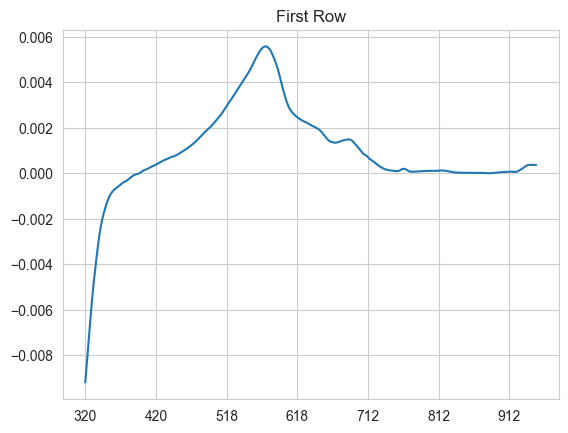

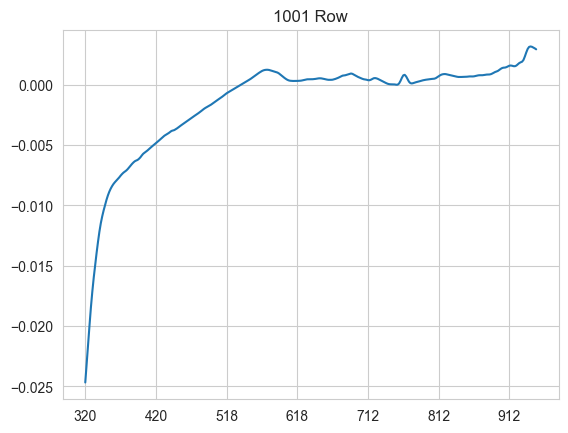

In [14]:
int_260428.iloc[0, 12:].plot()
plt.title('First Row')
plt.show()
int_260428.iloc[1000, 12:].plot()
plt.title('1001 Row')
plt.show()

**interpolation is showing a bump, need to check if this method is the best one**

In [15]:
# Create a list of your data values
values = [0.000983, 0.000907, 0.000837, 0.000770, 0.000704, 0.000644, 0.000594, 0.000551, 0.000509]

# Calculate the difference between consecutive points
diffs = [values[i+1] - values[i] for i in range(len(values)-1)]
print(diffs)

[-7.59999999999999e-05, -7.000000000000008e-05, -6.7e-05, -6.599999999999998e-05, -5.999999999999994e-05, -5.000000000000002e-05, -4.300000000000007e-05, -4.199999999999994e-05]


In [16]:
from scipy.interpolate import interp1d
import pandas as pd
import numpy as np
measured_wavelengths = np.array([
    320, 322, 324, 326, 328, 330, 332, 334, 336, 338, 340, 342, 344, 346, 348, 350,
    352, 354, 356, 358, 360, 362, 364, 366, 368, 370, 372, 374, 376, 378, 380, 382,
    384, 386, 388, 390, 392, 394, 396, 398, 400, 402, 404, 406, 408, 410, 412, 414,
    416, 418, 420, 422, 424, 426, 428, 430, 432, 434, 436, 438, 440, 442, 444, 446,
    448, 450, 452, 454, 456, 458, 460, 462, 464, 466, 468, 470, 472, 474, 476, 478,
    480, 482, 484, 486, 488, 490, 492, 494, 496, 498, 500, 502, 504, 506, 508, 510,
    512, 514, 516, 518, 520, 522, 524, 526, 528, 530, 532, 534, 536, 538, 540, 542,
    544, 546, 548, 550, 552, 554, 556, 558, 560, 562, 564, 566, 568, 570, 572, 574,
    576, 578, 580, 582, 584, 586, 588, 590, 592, 594, 596, 598, 600, 602, 604, 606,
    608, 610, 612, 614, 616, 618, 620, 622, 624, 626, 628, 630, 632, 634, 636, 638,
    640, 642, 644, 646, 648, 650, 652, 654, 656, 658, 660, 662, 664, 666, 668, 670,
    672, 674, 676, 678, 680, 682, 684, 686, 688, 690, 692, 694, 696, 698, 700, 702,
    704, 706, 708, 710, 712, 714, 716, 718, 720, 722, 724, 726, 728, 730, 732, 734,
    736, 738, 740, 742, 744, 746, 748, 750, 752, 754, 756, 758, 760, 762, 764, 766,
    768, 770, 772, 774, 776, 778, 780, 782, 784, 786, 788, 790, 792, 794, 796, 798,
    800, 802, 804, 806, 808, 810, 812, 814, 816, 818, 820, 822, 824, 826, 828, 830,
    832, 834, 836, 838, 840, 842, 844, 846, 848, 850, 852, 854, 856, 858, 860, 862,
    864, 866, 868, 870, 872, 874, 876, 878, 880, 882, 884, 886, 888, 890, 892, 894,
    896, 898, 900, 902, 904, 906, 908, 910, 912, 914, 916, 918, 920, 922, 924, 926,
    928, 930, 932, 934, 936, 938, 940, 942, 944, 946, 948, 950
])
# Define target bands
satellite_bands = [443,555, 665, 681, 709]
num_spectral_points = len(measured_wavelengths)

def extract_satellite_bands_linear(row):
    # 1. Slice and clean
    spectrum = row.iloc[12 : 12 + num_spectral_points].values
    temp_series = pd.Series(spectrum)
    spectrum_clean = temp_series.interpolate(method='linear', limit_direction='both').fillna(0).values

    # 2. Linear Interpolation (The 'Truth' Test)
    # kind='linear' forces a straight connection between measured points
    f = interp1d(measured_wavelengths, spectrum_clean, kind='linear')

    return pd.Series(f(satellite_bands), index=satellite_bands)

# --- APPLYING ---
df_linear = df_260428.copy()
new_bands_linear = df_linear.apply(extract_satellite_bands_linear, axis=1)

# Concatenate and sort
df_linear = pd.concat([df_linear, new_bands_linear], axis=1)
metadata_cols = list(df_linear.columns[:12])
data_cols = [c for c in df_linear.columns if c not in metadata_cols]
data_cols_sorted = sorted(data_cols, key=lambda x: int(x))
df_linear = df_linear[metadata_cols + data_cols_sorted]

print("Linear interpolation complete.")

Linear interpolation complete.


In [17]:
print('Raw:\n', df_260428.loc[0:5,'708':'710'],'\nPCHIP:\n', int_260428.loc[0:5,709], '\nPCHIP + SG Smoothing\n', df_final.loc[0:5,709], '\nLinear Int.:\n', df_linear.loc[0:5,709])

Raw:
         708       710
0  0.000837  0.000770
1  0.000708  0.000646
2  0.000775  0.000710
3  0.000760  0.000696
4  0.000772  0.000708
5  0.000768  0.000703 
PCHIP:
 0    0.000803
1    0.000677
2    0.000742
3    0.000728
4    0.000740
5    0.000735
Name: 709, dtype: float64 
PCHIP + SG Smoothing
 0    0.000803
1    0.000677
2    0.000742
3    0.000728
4    0.000740
5    0.000735
Name: 709, dtype: float64 
Linear Int.:
 0    0.000803
1    0.000677
2    0.000742
3    0.000728
4    0.000740
5    0.000736
Name: 709, dtype: float64


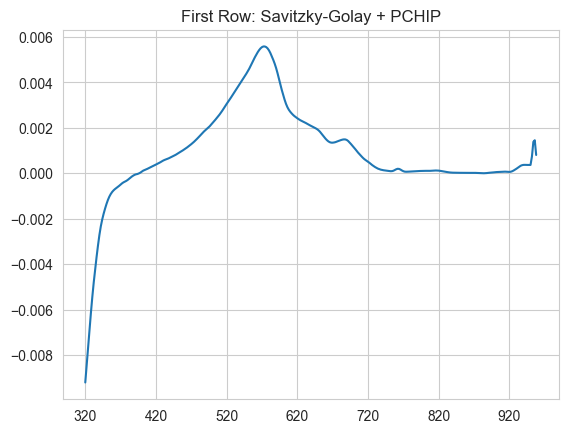

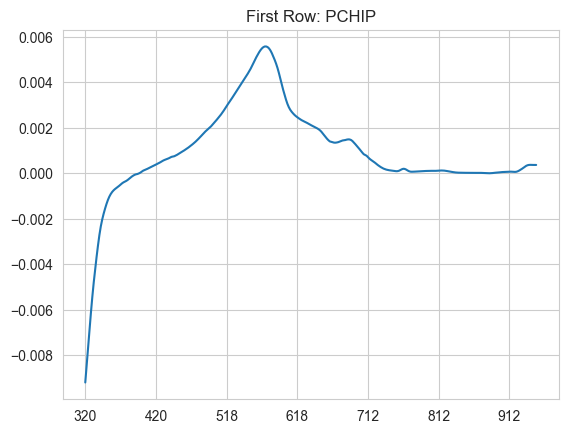

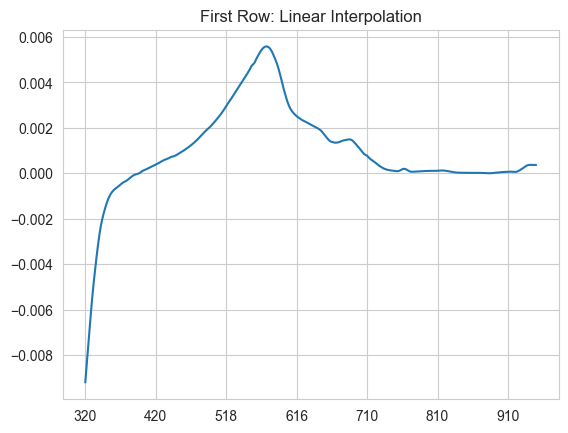

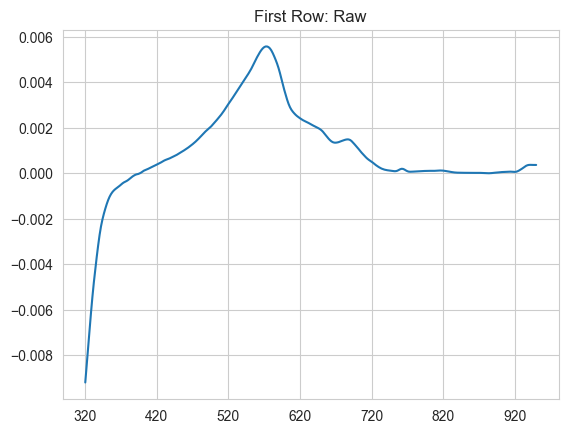

In [18]:
df_final.iloc[0, 12:].plot()
plt.title('First Row: Savitzky-Golay + PCHIP')
plt.show()
plt.show()
int_260428.iloc[0, 12:].plot()
plt.title('First Row: PCHIP')
plt.show()
df_linear.iloc[0, 12:].plot()
plt.title('First Row: Linear Interpolation')
plt.show()
df_260428.iloc[0, 12:].plot()
plt.title('First Row: Raw')
plt.show()

**Doron et al, 2007 uses linear interpolation, along with Salem et al, Cael et al, Zibordi et al, and Ogashawara et al (See Rrs Analysis subfolder in Anara)

In [19]:
lin_260428 = df_linear.copy()

In [20]:
lin_260428['Timestamp'] = pd.to_datetime(lin_260428[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])

In [21]:
lin_260428 = lin_260428.set_index('Timestamp')

In [22]:
lin_260428

,Year,Month,Day,Hour,Minute,Second,Flag Light Availability,Flag Light Quality,Flag Weather,Flag Sunglint (Lw),...,932,934,936,938,940,942,944,946,948,950
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-04-28 11:23:07,2026,4,28,11,23,7,1,1,1,1,...,0.000241,0.000288,0.000328,0.000354,0.000367,0.000369,0.000365,0.000365,0.000365,0.000365
2026-04-28 11:23:11,2026,4,28,11,23,11,1,1,1,1,...,0.000202,0.000246,0.000274,0.000286,0.000294,0.000303,0.000306,0.000308,0.000309,0.000308
2026-04-28 11:23:14,2026,4,28,11,23,14,1,1,1,1,...,0.000209,0.000261,0.000312,0.000349,0.000366,0.000366,0.000362,0.000357,0.000351,0.000345
2026-04-28 11:23:17,2026,4,28,11,23,17,1,1,1,1,...,0.000221,0.000277,0.000320,0.000341,0.000343,0.000338,0.000338,0.000339,0.000341,0.000342
2026-04-28 11:23:20,2026,4,28,11,23,20,1,1,1,1,...,0.000228,0.000280,0.000318,0.000340,0.000353,0.000361,0.000359,0.000355,0.000349,0.000341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-28 16:48:38,2026,4,28,16,48,38,1,1,1,1,...,0.000026,0.000040,0.000049,0.000054,0.000053,0.000051,0.000051,0.000051,0.000052,0.000053
2026-04-28 16:48:41,2026,4,28,16,48,41,1,1,1,1,...,0.000027,0.000041,0.000056,0.000071,0.000081,0.000083,0.000084,0.000084,0.000084,0.000083
2026-04-28 16:48:44,2026,4,28,16,48,44,1,1,1,1,...,-0.000018,-0.000007,0.000014,0.000035,0.000044,0.000043,0.000032,0.000022,0.000011,-0.000001


**Got TriOS data how I want it for now, need to pull the station data with times to start filtering**

## Align Times (need to run)

In [38]:
stations = pd.read_excel("C:/Users/25298423/OneDrive - National University of Ireland, Galway/date_station_secchi_Plan2.xlsx")
stations['Time_Start_delta'] = pd.to_timedelta(stations['Time_Start'].astype(str))
stations['Time_End_delta'] = pd.to_timedelta(stations['Time_End'].astype(str))
stations['Timestamp_Start'] = stations['Date'] + stations['Time_Start_delta']
stations['Timestamp_End'] = stations['Date'] + stations['Time_End_delta']
stations = stations.drop(columns=['Time_Start_delta', 'Time_End_delta'])

In [44]:
stations

,Date,Time_Start,Time_End,Site,Longitude,Latitude,Secchi_Depth(m),Notes,Timestamp_Start,Timestamp_End,latitude_dec,longitude_dec
0,2026-04-28,11:28:00,11:38:00,ISO-01,9° 2.3724' W,53° 15.7862’N,3.36,NaN,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540
1,2026-04-28,11:43:00,11:50:00,ISO-02,9° 2.2235’ W,53° 15.6392’ N,4.06,NaN,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058
2,2026-04-28,12:02:00,12:09:00,ISO-03,9° 2.2161’ W,53° 15.0466’ N,4.13,NaN,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935
3,2026-04-28,12:18:00,12:26:00,ISO-04,9° 2.4973’ W,53° 14.6952’ N,NaN,NaN,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622
4,2026-04-28,15:18:00,15:25:00,ISO-08A,8° 56.1705’ W,53° 8.5038’ N,2.53,NaN,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175
5,2026-04-28,15:41:00,15:47:00,ISO-08B,8° 56.9037’ W,53° 9.5003’ N,4.88,NaN,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395
6,2026-04-28,15:58:00,16:02:00,ISO-09,8° 57.3280’ W,53° 10.0637’ N,4.25,NaN,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467
7,2026-04-28,16:13:00,16:15:00,ISO-10,8° 57.7330’ W,53° 10.5538’ N,4.39,NaN,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217
8,2026-04-28,16:24:00,16:34:00,ISO-11,8° 58.2232’ W,53° 10.8128’ N,4.59,NaN,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387
9,2026-04-28,16:43:00,16:48:00,ISO-12,8° 58.7559’ W,53° 10.7636’ N,5.05,NaN,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265


In [39]:
decimal_degrees_lon = []
for lon in stations['Longitude']:
    degree = float(re.findall(r'^\d{1,2}(?=\°\s)', lon)[0])
    dec_minute = float(re.findall(r'\d{1,2}\.\d{3,4}', lon)[0])
    dec_deg = degree + (dec_minute / 60)
    if 'W' in lon:
        dec_deg = -dec_deg
    dec_deg = round(dec_deg, 6)
    decimal_degrees_lon.append(dec_deg)


decimal_degrees_lat = []
for lat in stations['Latitude']:
    degree = float(re.findall(r'^\d{1,2}(?=\°\s)', lat)[0])
    dec_minute = float(re.findall(r'\d{1,2}\.\d{3,4}', lat)[0])
    dec_deg = degree + (dec_minute / 60)
    dec_deg = round(dec_deg, 6)
    decimal_degrees_lat.append(dec_deg)


stations['latitude_dec'] = decimal_degrees_lat
stations['longitude_dec'] = decimal_degrees_lon

In [40]:
station_times = stations[['Site','Timestamp_Start','Timestamp_End', 'latitude_dec','longitude_dec']]
station_times

,Site,Timestamp_Start,Timestamp_End,latitude_dec,longitude_dec
0,ISO-01,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540
1,ISO-02,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058
2,ISO-03,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935
3,ISO-04,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622
4,ISO-08A,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175
5,ISO-08B,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395
6,ISO-09,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467
7,ISO-10,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217
8,ISO-11,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387
9,ISO-12,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265


### Filtering Test Dataset to Sampling Times and Dates

In [26]:
# 1. Initialize an empty list
filtered_data_list = []

# 2. Iterate through stations and filter
for idx, row in station_times.iterrows():
    # Define the time range for the current station
    start = row['Timestamp_Start']
    end = row['Timestamp_End']

    # Create the mask
    mask = (lin_260428.index >= start) & (lin_260428.index <= end)

    # Extract the subset
    subset = lin_260428.loc[mask].copy()

    # Add the 'Site' column from station_times
    if not subset.empty:
        subset['Site'] = row['Site']
        subset['Latitude'] = row['latitude_dec']
        subset['Longitude'] = row['longitude_dec']

        filtered_data_list.append(subset)

# 3. Consolidate into a single master dataframe
on_station_260428 = pd.concat(filtered_data_list)

In [45]:
on_station_260428

,Year,Month,Day,Hour,Minute,Second,Flag Light Availability,Flag Light Quality,Flag Weather,Flag Sunglint (Lw),...,940,942,944,946,948,950,Site,Latitude,Longitude,Date
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-04-28 11:28:02,2026,4,28,11,28,2,1,1,1,1,...,0.000237,0.000242,0.000247,0.000251,0.000254,0.000257,ISO-01,53.263103,-9.039540,2026-04-28
2026-04-28 11:28:05,2026,4,28,11,28,5,1,1,1,1,...,0.000232,0.000240,0.000235,0.000230,0.000224,0.000217,ISO-01,53.263103,-9.039540,2026-04-28
2026-04-28 11:28:08,2026,4,28,11,28,8,1,1,1,1,...,0.000257,0.000249,0.000232,0.000220,0.000209,0.000200,ISO-01,53.263103,-9.039540,2026-04-28
2026-04-28 11:28:11,2026,4,28,11,28,11,1,1,1,1,...,0.000220,0.000210,0.000204,0.000207,0.000211,0.000220,ISO-01,53.263103,-9.039540,2026-04-28
2026-04-28 11:28:14,2026,4,28,11,28,14,1,1,1,1,...,0.000264,0.000273,0.000268,0.000260,0.000250,0.000238,ISO-01,53.263103,-9.039540,2026-04-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-28 16:47:45,2026,4,28,16,47,45,1,1,1,1,...,0.000213,0.000211,0.000199,0.000188,0.000176,0.000162,ISO-12,53.179393,-8.979265,2026-04-28
2026-04-28 16:47:48,2026,4,28,16,47,48,1,1,1,1,...,0.000109,0.000100,0.000093,0.000090,0.000089,0.000088,ISO-12,53.179393,-8.979265,2026-04-28
2026-04-28 16:47:52,2026,4,28,16,47,52,1,1,1,1,...,0.000281,0.000287,0.000283,0.000277,0.000270,0.000263,ISO-12,53.179393,-8.979265,2026-04-28


In [46]:
on_station_260428['Date'] = on_station_260428.index.date

In [61]:
on_station_260428['Flag Light Availability'].unique()

array([1])

In [62]:
on_station_260428 = on_station_260428[on_station_260428['Flag Weather'] == 1]

In [63]:
site_means_260428 = on_station_260428.groupby(['Site', 'Date', 'Latitude', 'Longitude']).mean(numeric_only=True)

In [64]:
site_means_260428

,,,,Year,Month,Day,Hour,Minute,Second,Flag Light Availability,Flag Light Quality,Flag Weather,Flag Sunglint (Lw),...,932,934,936,938,940,942,944,946,948,950
Site,Date,Latitude,Longitude,,,,,,,,,,,,,,,,,,,,,
ISO-01,2026-04-28,53.263103,-9.039540,2026.0,4.0,28.0,11.000000,32.556701,29.463918,1.0,1.0,1.0,1.0,...,0.000139,0.000170,0.000196,0.000213,0.000221,0.000223,0.000224,0.000224,0.000225,0.000226
ISO-02,2026-04-28,53.260653,-9.037058,2026.0,4.0,28.0,11.000000,46.029412,29.389706,1.0,1.0,1.0,1.0,...,0.000133,0.000164,0.000189,0.000206,0.000214,0.000216,0.000215,0.000214,0.000213,0.000212
ISO-03,2026-04-28,53.250777,-9.036935,2026.0,4.0,28.0,12.000000,5.007353,30.382353,1.0,1.0,1.0,1.0,...,0.000116,0.000143,0.000165,0.000179,0.000186,0.000187,0.000187,0.000187,0.000186,0.000186
ISO-04,2026-04-28,53.244920,-9.041622,2026.0,4.0,28.0,12.000000,21.468966,29.862069,1.0,1.0,1.0,1.0,...,0.000146,0.000180,0.000208,0.000227,0.000236,0.000237,0.000235,0.000234,0.000232,0.000230
ISO-08A,2026-04-28,53.141730,-8.936175,2026.0,4.0,28.0,15.000000,21.008264,29.223140,1.0,1.0,1.0,1.0,...,0.000112,0.000145,0.000171,0.000189,0.000195,0.000194,0.000192,0.000189,0.000187,0.000185
ISO-08B,2026-04-28,53.158338,-8.948395,2026.0,4.0,28.0,15.000000,43.465347,29.623762,1.0,1.0,1.0,1.0,...,0.000074,0.000096,0.000116,0.000129,0.000134,0.000135,0.000135,0.000134,0.000134,0.000134
ISO-09,2026-04-28,53.167728,-8.955467,2026.0,4.0,28.0,15.493506,29.870130,28.636364,1.0,1.0,1.0,1.0,...,0.000097,0.000123,0.000146,0.000163,0.000170,0.000169,0.000167,0.000165,0.000164,0.000162
ISO-10,2026-04-28,53.175897,-8.962217,2026.0,4.0,28.0,16.000000,13.513514,29.216216,1.0,1.0,1.0,1.0,...,0.000311,0.000389,0.000458,0.000506,0.000526,0.000525,0.000519,0.000514,0.000510,0.000505
ISO-11,2026-04-28,53.180213,-8.970387,2026.0,4.0,28.0,16.000000,28.616667,29.772222,1.0,1.0,1.0,1.0,...,0.000164,0.000213,0.000256,0.000285,0.000296,0.000293,0.000287,0.000282,0.000277,0.000272


In [65]:
site_means_260428.drop(columns=['Year','Month','Day','Hour','Minute','Second', 'Flag Light Availability', 'Flag Light Quality', 'Flag Weather', 'Flag Sunglint (Lw)','Flag Sunglint (Rrs)', 'minRrs'], inplace=True)

In [66]:
site_means_260428 = site_means_260428.reset_index(level=['Date', 'Latitude', 'Longitude'])

In [67]:
site_means_260428

,Date,Latitude,Longitude,320,322,324,326,328,330,332,...,932,934,936,938,940,942,944,946,948,950
Site,,,,,,,,,,,,,,,,,,,,,
ISO-01,2026-04-28,53.263103,-9.039540,-0.005708,-0.005151,-0.004596,-0.004042,-0.003492,-0.002992,-0.002540,...,0.000139,0.000170,0.000196,0.000213,0.000221,0.000223,0.000224,0.000224,0.000225,0.000226
ISO-02,2026-04-28,53.260653,-9.037058,-0.005581,-0.005033,-0.004488,-0.003945,-0.003406,-0.002917,-0.002474,...,0.000133,0.000164,0.000189,0.000206,0.000214,0.000216,0.000215,0.000214,0.000213,0.000212
ISO-03,2026-04-28,53.250777,-9.036935,-0.005823,-0.005282,-0.004743,-0.004205,-0.003671,-0.003188,-0.002752,...,0.000116,0.000143,0.000165,0.000179,0.000186,0.000187,0.000187,0.000187,0.000186,0.000186
ISO-04,2026-04-28,53.244920,-9.041622,-0.006524,-0.005931,-0.005342,-0.004754,-0.004172,-0.003647,-0.003173,...,0.000146,0.000180,0.000208,0.000227,0.000236,0.000237,0.000235,0.000234,0.000232,0.000230
ISO-08A,2026-04-28,53.141730,-8.936175,-0.006117,-0.005541,-0.004969,-0.004397,-0.003830,-0.003316,-0.002852,...,0.000112,0.000145,0.000171,0.000189,0.000195,0.000194,0.000192,0.000189,0.000187,0.000185
ISO-08B,2026-04-28,53.158338,-8.948395,-0.006501,-0.005923,-0.005347,-0.004772,-0.004199,-0.003677,-0.003207,...,0.000074,0.000096,0.000116,0.000129,0.000134,0.000135,0.000135,0.000134,0.000134,0.000134
ISO-09,2026-04-28,53.167728,-8.955467,-0.006526,-0.005954,-0.005383,-0.004811,-0.004237,-0.003708,-0.003226,...,0.000097,0.000123,0.000146,0.000163,0.000170,0.000169,0.000167,0.000165,0.000164,0.000162
ISO-10,2026-04-28,53.175897,-8.962217,-0.007164,-0.006481,-0.005800,-0.005120,-0.004443,-0.003823,-0.003258,...,0.000311,0.000389,0.000458,0.000506,0.000526,0.000525,0.000519,0.000514,0.000510,0.000505
ISO-11,2026-04-28,53.180213,-8.970387,-0.006365,-0.005768,-0.005169,-0.004569,-0.003966,-0.003403,-0.002892,...,0.000164,0.000213,0.000256,0.000285,0.000296,0.000293,0.000287,0.000282,0.000277,0.000272


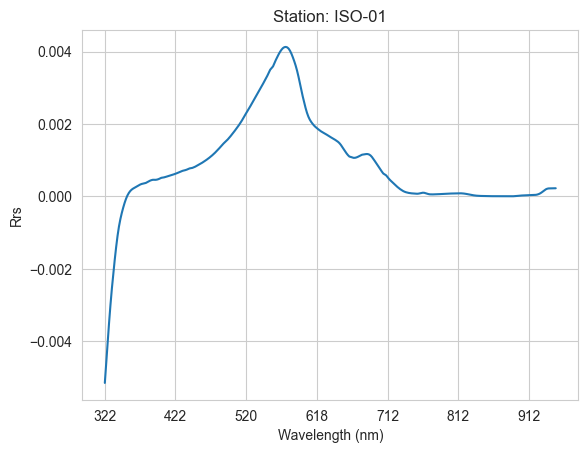

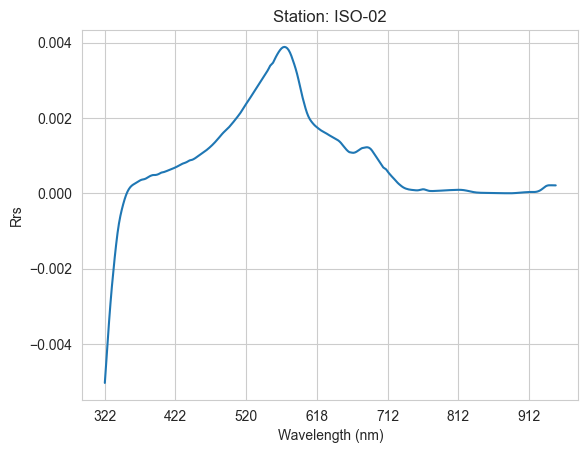

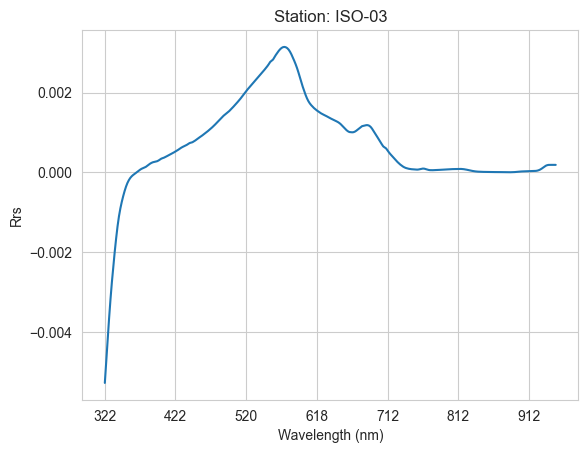

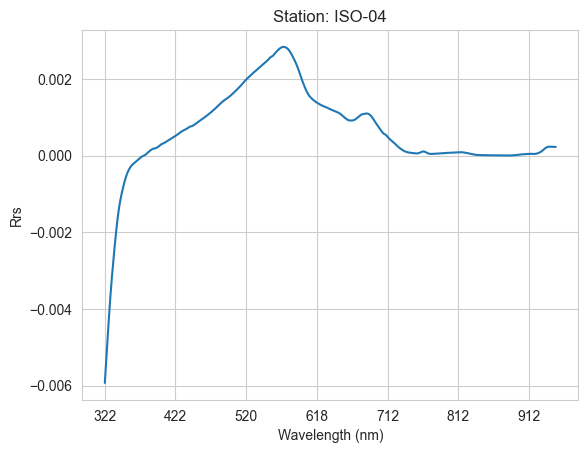

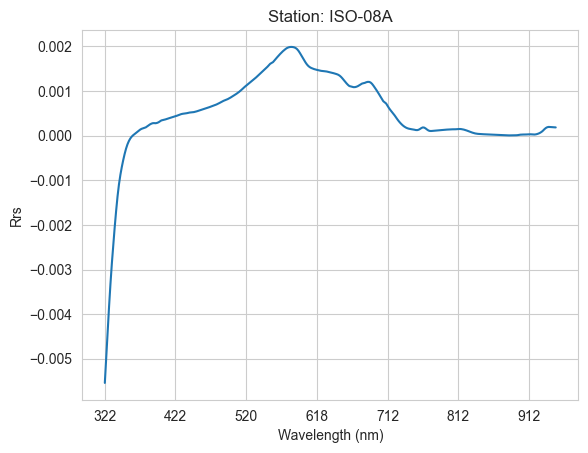

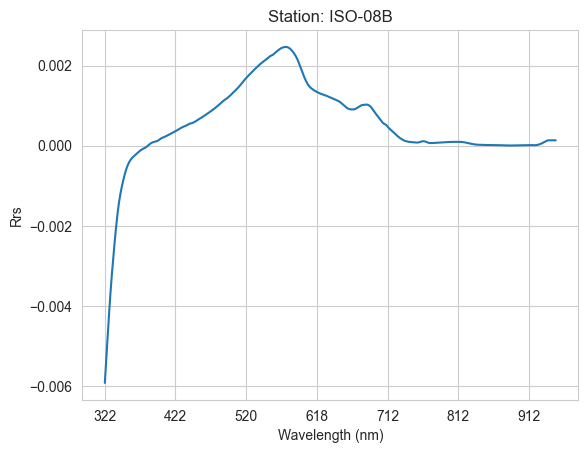

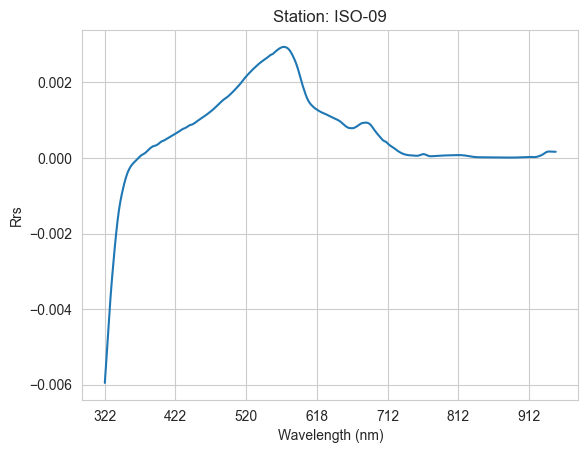

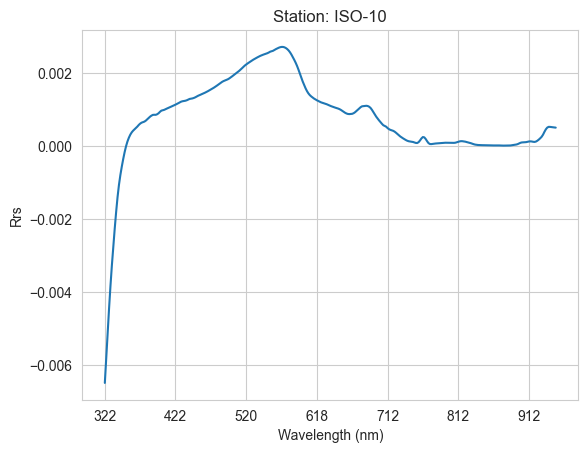

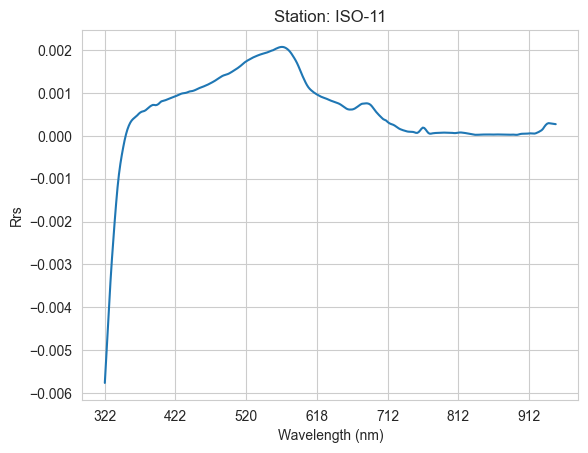

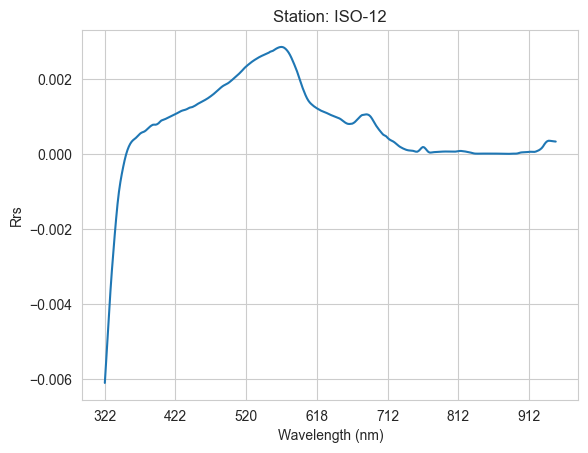

In [68]:
for idx, row in site_means_260428.iterrows():
    # Slice the row by integer position
    # We take from column 4 onwards to grab only the spectral data
    spectral_data = row.iloc[4:]

    spectral_data.plot(title=f"Station: {idx}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Rrs")
    plt.show()

## Big Function to Process All the Rrs Data from Sampling

In [69]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# 1. Define your list of files
file_paths = [
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260429/Matlab/InstrumentData/260429/260429workingfile/20260429_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260501/Matlab/InstrumentData/260501/260501workingfile/20260501_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260506/Matlab/InstrumentData/260506/260506workingfile/20260506_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260510/Matlab/InstrumentData/260510/260510workingfile/20260510_Rrs.dat"
]

def process_cruise_data(path, station_times_df):
    # Extract date (e.g., '260429') from the filename
    date_str = path.split('/')[-1].split('_')[0][2:]

    # Read data
    df = pd.read_csv(path, delimiter='\t', skiprows=49)

    # Time processing
    df['Timestamp'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])
    df = df.set_index('Timestamp')

    # Interpolation Logic (Linear)
    satellite_bands = [443, 555, 665, 681, 709]
    def extract_bands(row):
        spectrum = row.iloc[12 : 12 + 316].values # Assuming 316 is your fixed wavelength count
        f = interp1d(measured_wavelengths, pd.Series(spectrum).interpolate(method='linear', limit_direction='both').fillna(0), kind='linear')
        return pd.Series(f(satellite_bands), index=satellite_bands)

    new_bands = df.apply(extract_bands, axis=1)
    df = pd.concat([df, new_bands], axis=1)

    # Filtering Logic
    filtered_list = []

    for _, row in station_times_df.iterrows():
        mask = (df.index >= row['Timestamp_Start']) & (df.index <= row['Timestamp_End'])
        subset = df.loc[mask].copy()
        if not subset.empty:
            subset['Site'] = row['Site']
            subset['Latitude'] = row['latitude_dec']
            subset['Longitude'] = row['longitude_dec']
            ## flags
            flag_cols = [
                'Flag Light Availability', 'Flag Light Quality',
                'Flag Weather', 'Flag Sunglint (Lw)', 'Flag Sunglint (Rrs)'
            ]

            # Keep rows where all specified flag columns are exactly 1
            flag_mask = (subset[flag_cols] == 1).all(axis=1)
            subset = subset.loc[flag_mask]

            filtered_list.append(subset)

    on_station_df = pd.concat(filtered_list)

    on_station_df['Date'] = on_station_df.index.date

    # Group and Clean
    group_keys = ['Site', 'Date', 'Latitude', 'Longitude']
    site_means = on_station_df.groupby(group_keys).mean(numeric_only=True)

    drop_cols = ['Year','Month','Day','Hour','Minute','Second', 'Flag Light Availability',
                 'Flag Light Quality', 'Flag Weather', 'Flag Sunglint (Lw)',
                 'Flag Sunglint (Rrs)', 'minRrs']
    site_means.drop(columns=drop_cols, errors='ignore', inplace=True)
    site_means = site_means.reset_index(level=['Date', 'Latitude', 'Longitude'])
    return date_str, site_means

# 2. Run the loop
results = {}
for path in file_paths:
    date_key, df_result = process_cruise_data(path, station_times)
    results[f"site_means_{date_key}"] = df_result
    print(f"Processed: {date_key}")

# To access them later:
# site_means_260429 = results['site_means_260429']

Processed: 260429
Processed: 260501
Processed: 260506
Processed: 260510


In [70]:
site_means_260429 = results['site_means_260429']
site_means_260501 = results['site_means_260501']
site_means_260506 = results['site_means_260506']
site_means_260510 = results['site_means_260510']

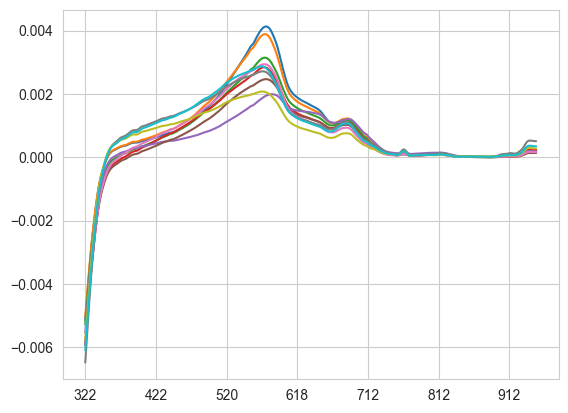

In [71]:
for idx, row in site_means_260428.iterrows():
    # Slice the row by integer position
    # We take from column 4 onwards to grab only the spectral data
    spectral_data = row.iloc[4:]

    spectral_data.plot()

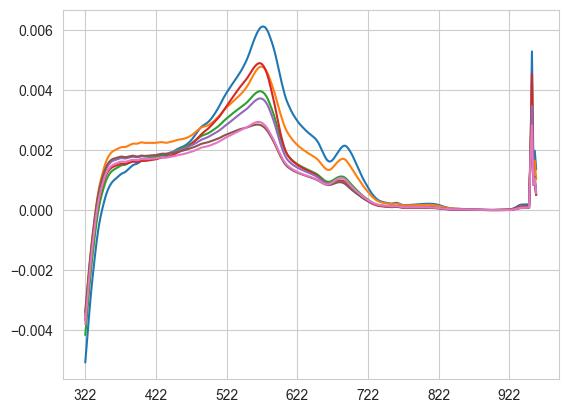

In [72]:
for idx, row in site_means_260429.iterrows():
    # Slice the row by integer position
    # We take from column 4 onwards to grab only the spectral data
    spectral_data = row.iloc[4:]

    spectral_data.plot()

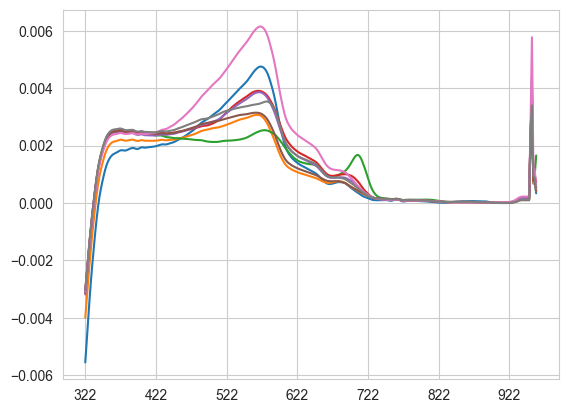

In [73]:
for idx, row in site_means_260501.iterrows():
    # Slice the row by integer position
    # We take from column 4 onwards to grab only the spectral data
    spectral_data = row.iloc[4:]

    spectral_data.plot()

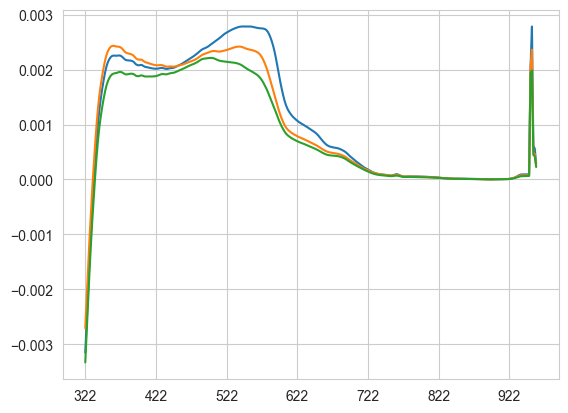

In [74]:
for idx, row in site_means_260506.iterrows():
    # Slice the row by integer position
    # We take from column 4 onwards to grab only the spectral data
    spectral_data = row.iloc[4:]

    spectral_data.plot()

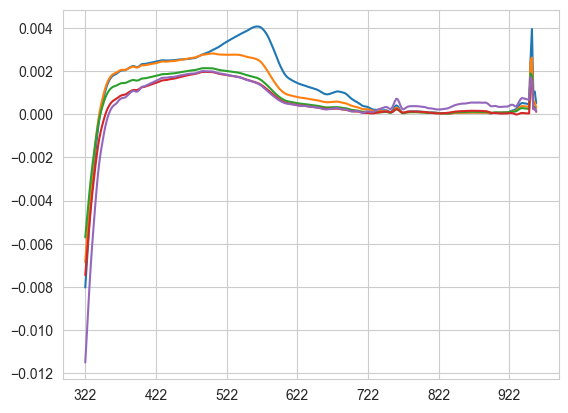

In [75]:
for idx, row in site_means_260510.iterrows():
    # Slice the row by integer position
    # We take from column 4 onwards to grab only the spectral data
    spectral_data = row.iloc[4:]

    spectral_data.plot()

In [77]:
dfs = [site_means_260428, site_means_260429, site_means_260501, site_means_260506, site_means_260510]

# 2. Concatenate them vertically (axis=0)
all_site_means = pd.concat(dfs, axis=0)

# 3. If 'Site' is currently the index, reset it to make it a column
all_site_means = all_site_means.reset_index()

# 4. Final verification:
# This should now look exactly like your first dataframe,
# but with the added rows from all your cruise days.
print(all_site_means.head())

      Site        Date   Latitude  Longitude       320       322       324  \
0   ISO-01  2026-04-28  53.263103  -9.039540 -0.005708 -0.005151 -0.004596   
1   ISO-02  2026-04-28  53.260653  -9.037058 -0.005581 -0.005033 -0.004488   
2   ISO-03  2026-04-28  53.250777  -9.036935 -0.005823 -0.005282 -0.004743   
3   ISO-04  2026-04-28  53.244920  -9.041622 -0.006524 -0.005931 -0.005342   
4  ISO-08A  2026-04-28  53.141730  -8.936175 -0.006117 -0.005541 -0.004969   

        326       328       330  ...       932       934       936       938  \
0 -0.004042 -0.003492 -0.002992  ...  0.000139  0.000170  0.000196  0.000213   
1 -0.003945 -0.003406 -0.002917  ...  0.000133  0.000164  0.000189  0.000206   
2 -0.004205 -0.003671 -0.003188  ...  0.000116  0.000143  0.000165  0.000179   
3 -0.004754 -0.004172 -0.003647  ...  0.000146  0.000180  0.000208  0.000227   
4 -0.004397 -0.003830 -0.003316  ...  0.000112  0.000145  0.000171  0.000189   

        940       942       944       946       94

In [78]:
all_site_means

,Site,Date,Latitude,Longitude,320,322,324,326,328,330,...,932,934,936,938,940,942,944,946,948,950
0,ISO-01,2026-04-28,53.263103,-9.039540,-0.005708,-0.005151,-0.004596,-0.004042,-0.003492,-0.002992,...,0.000139,1.704278e-04,0.000196,0.000213,0.000221,0.000223,0.000224,0.000224,0.000225,0.000226
1,ISO-02,2026-04-28,53.260653,-9.037058,-0.005581,-0.005033,-0.004488,-0.003945,-0.003406,-0.002917,...,0.000133,1.639706e-04,0.000189,0.000206,0.000214,0.000216,0.000215,0.000214,0.000213,0.000212
2,ISO-03,2026-04-28,53.250777,-9.036935,-0.005823,-0.005282,-0.004743,-0.004205,-0.003671,-0.003188,...,0.000116,1.431176e-04,0.000165,0.000179,0.000186,0.000187,0.000187,0.000187,0.000186,0.000186
3,ISO-04,2026-04-28,53.244920,-9.041622,-0.006524,-0.005931,-0.005342,-0.004754,-0.004172,-0.003647,...,0.000146,1.797586e-04,0.000208,0.000227,0.000236,0.000237,0.000235,0.000234,0.000232,0.000230
4,ISO-08A,2026-04-28,53.141730,-8.936175,-0.006117,-0.005541,-0.004969,-0.004397,-0.003830,-0.003316,...,0.000112,1.445868e-04,0.000171,0.000189,0.000195,0.000194,0.000192,0.000189,0.000187,0.000185
5,ISO-08B,2026-04-28,53.158338,-8.948395,-0.006501,-0.005923,-0.005347,-0.004772,-0.004199,-0.003677,...,0.000074,9.643564e-05,0.000116,0.000129,0.000134,0.000135,0.000135,0.000134,0.000134,0.000134
6,ISO-09,2026-04-28,53.167728,-8.955467,-0.006526,-0.005954,-0.005383,-0.004811,-0.004237,-0.003708,...,0.000097,1.228571e-04,0.000146,0.000163,0.000170,0.000169,0.000167,0.000165,0.000164,0.000162
7,ISO-10,2026-04-28,53.175897,-8.962217,-0.007164,-0.006481,-0.005800,-0.005120,-0.004443,-0.003823,...,0.000311,3.889189e-04,0.000458,0.000506,0.000526,0.000525,0.000519,0.000514,0.000510,0.000505
8,ISO-11,2026-04-28,53.180213,-8.970387,-0.006365,-0.005768,-0.005169,-0.004569,-0.003966,-0.003403,...,0.000164,2.134333e-04,0.000256,0.000285,0.000296,0.000293,0.000287,0.000282,0.000277,0.000272
9,ISO-12,2026-04-28,53.179393,-8.979265,-0.006719,-0.006101,-0.005481,-0.004858,-0.004228,-0.003637,...,0.000210,2.698851e-04,0.000319,0.000351,0.000364,0.000362,0.000356,0.000351,0.000347,0.000342


## Now, Can save this to a csv and bring it over to Plan 2!

In [79]:
all_site_means.to_csv('hyperspectral_sampling_means.csv', index=False)

## Using Spectral Response Functions for Data

In [41]:
file_paths = [
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260428/Matlab/InstrumentData/260428/260428workingfile/20260428_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260429/Matlab/InstrumentData/260429/260429workingfile/20260429_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260501/Matlab/InstrumentData/260501/260501workingfile/20260501_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260506/Matlab/InstrumentData/260506/260506workingfile/20260506_Rrs.dat",
    "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Croot, Peters files - ISOLUME/Equipment Loan Spring 2026/Radiometer Samples/TRIOS/CruiseData/260510/Matlab/InstrumentData/260510/260510workingfile/20260510_Rrs.dat"
]

In [45]:
station_times

,Site,Timestamp_Start,Timestamp_End,latitude_dec,longitude_dec
0,ISO-01,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540
1,ISO-02,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058
2,ISO-03,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935
3,ISO-04,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622
4,ISO-08A,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175
5,ISO-08B,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395
6,ISO-09,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467
7,ISO-10,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217
8,ISO-11,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387
9,ISO-12,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265


In [46]:
def process_cruise_data_SRF(path, station_times_df):
    # Extract date (e.g., '260429') from the filename
    date_str = path.split('/')[-1].split('_')[0][2:]

    # Read data
    df = pd.read_csv(path, delimiter='\t', skiprows=49)

    # Time processing
    df['Timestamp'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])
    df = df.set_index('Timestamp')

    # Filtering Logic
    filtered_list = []

    for _, row in station_times_df.iterrows():
        mask = (df.index >= row['Timestamp_Start']) & (df.index <= row['Timestamp_End'])
        subset = df.loc[mask].copy()
        if not subset.empty:
            subset['Site'] = row['Site']
            subset['Latitude'] = row['latitude_dec']
            subset['Longitude'] = row['longitude_dec']
            subset['Timestamp_Start'] = row['Timestamp_Start']
            subset['Timestamp_End'] = row['Timestamp_End']
            ## flags
            flag_cols = [
                'Flag Light Availability', 'Flag Light Quality',
                'Flag Weather', 'Flag Sunglint (Lw)', 'Flag Sunglint (Rrs)'
            ]

            # Keep rows where all specified flag columns are exactly 1
            flag_mask = (subset[flag_cols] == 1).all(axis=1)
            subset = subset.loc[flag_mask]

            filtered_list.append(subset)

    on_station_df = pd.concat(filtered_list)

    on_station_df['Date'] = on_station_df.index.date

    # Group and Clean
    group_keys = ['Site', 'Date', 'Timestamp_Start', 'Timestamp_End','Latitude', 'Longitude']
    site_means = on_station_df.groupby(group_keys).mean(numeric_only=True)

    drop_cols = ['Year','Month','Day','Hour','Minute','Second', 'Flag Light Availability',
                 'Flag Light Quality', 'Flag Weather', 'Flag Sunglint (Lw)',
                 'Flag Sunglint (Rrs)', 'minRrs']
    site_means.drop(columns=drop_cols, errors='ignore', inplace=True)
    site_means = site_means.reset_index(level=['Date','Timestamp_Start', 'Timestamp_End', 'Latitude', 'Longitude'])
    return date_str, site_means



In [47]:
results = {}
for path in file_paths:
    date_key, df_result = process_cruise_data_SRF(path, station_times)
    results[f"site_means_{date_key}"] = df_result
    print(f"Processed: {date_key}")

# To access them later:
# site_means_260429 = results['site_means_260429']
site_means_260428_SRF = results['site_means_260428']
site_means_260429_SRF = results['site_means_260429']
site_means_260501_SRF = results['site_means_260501']
site_means_260506_SRF = results['site_means_260506']
site_means_260510_SRF = results['site_means_260510']

Processed: 260428
Processed: 260429
Processed: 260501
Processed: 260506
Processed: 260510


In [48]:
dfs_SRF = [site_means_260428_SRF, site_means_260429_SRF, site_means_260501_SRF, site_means_260506_SRF, site_means_260510_SRF]

# 2. Concatenate them vertically (axis=0)
all_site_means_SRF = pd.concat(dfs_SRF, axis=0)

# 3. If 'Site' is currently the index, reset it to make it a column
all_site_means_SRF = all_site_means_SRF.reset_index()

# 4. Final verification:
# This should now look exactly like your first dataframe,
# but with the added rows from all your cruise days.
print(all_site_means_SRF.head())

      Site        Date     Timestamp_Start       Timestamp_End   Latitude  \
0   ISO-01  2026-04-28 2026-04-28 11:28:00 2026-04-28 11:38:00  53.263103   
1   ISO-02  2026-04-28 2026-04-28 11:43:00 2026-04-28 11:50:00  53.260653   
2   ISO-03  2026-04-28 2026-04-28 12:02:00 2026-04-28 12:09:00  53.250777   
3   ISO-04  2026-04-28 2026-04-28 12:18:00 2026-04-28 12:26:00  53.244920   
4  ISO-08A  2026-04-28 2026-04-28 15:18:00 2026-04-28 15:25:00  53.141730   

   Longitude       320       322       324       326  ...       932       934  \
0  -9.039540 -0.005708 -0.005151 -0.004596 -0.004042  ...  0.000139  0.000170   
1  -9.037058 -0.005581 -0.005033 -0.004488 -0.003945  ...  0.000133  0.000164   
2  -9.036935 -0.005823 -0.005282 -0.004743 -0.004205  ...  0.000116  0.000143   
3  -9.041622 -0.006524 -0.005931 -0.005342 -0.004754  ...  0.000146  0.000180   
4  -8.936175 -0.006117 -0.005541 -0.004969 -0.004397  ...  0.000112  0.000145   

        936       938       940       942       94

In [49]:
list(all_site_means_SRF.columns)

['Site',
 'Date',
 'Timestamp_Start',
 'Timestamp_End',
 'Latitude',
 'Longitude',
 '320',
 '322',
 '324',
 '326',
 '328',
 '330',
 '332',
 '334',
 '336',
 '338',
 '340',
 '342',
 '344',
 '346',
 '348',
 '350',
 '352',
 '354',
 '356',
 '358',
 '360',
 '362',
 '364',
 '366',
 '368',
 '370',
 '372',
 '374',
 '376',
 '378',
 '380',
 '382',
 '384',
 '386',
 '388',
 '390',
 '392',
 '394',
 '396',
 '398',
 '400',
 '402',
 '404',
 '406',
 '408',
 '410',
 '412',
 '414',
 '416',
 '418',
 '420',
 '422',
 '424',
 '426',
 '428',
 '430',
 '432',
 '434',
 '436',
 '438',
 '440',
 '442',
 '444',
 '446',
 '448',
 '450',
 '452',
 '454',
 '456',
 '458',
 '460',
 '462',
 '464',
 '466',
 '468',
 '470',
 '472',
 '474',
 '476',
 '478',
 '480',
 '482',
 '484',
 '486',
 '488',
 '490',
 '492',
 '494',
 '496',
 '498',
 '500',
 '502',
 '504',
 '506',
 '508',
 '510',
 '512',
 '514',
 '516',
 '518',
 '520',
 '522',
 '524',
 '526',
 '528',
 '530',
 '532',
 '534',
 '536',
 '538',
 '540',
 '542',
 '544',
 '546',
 '548

## Load in SRFs for S3A and S3B OLCI

In [24]:
olci_a_SRF = xr.open_dataset("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/SRF_Sentinel/S3A_OL_SRF_20160713_mean_rsr.nc4")
olci_a_SRF.variables

Frozen({'mean_spectral_response_function': <xarray.Variable (band_number: 21, wavelength: 200)> Size: 17kB
[4200 values with dtype=float32]
Attributes:
    long_name:  mean relative spectral response function
    unit:       1, 'mean_spectral_response_function_wavelength': <xarray.Variable (band_number: 21, wavelength: 200)> Size: 17kB
[4200 values with dtype=float32]
Attributes:
    long_name:  mean relative spectral response wavelength
    unit:       nm, 'solar_irradiance': <xarray.Variable (band_number: 21)> Size: 84B
[21 values with dtype=float32]
Attributes:
    long_name:  solar irradiance for mean srf
    unit:       mW/m2/nm
    comment:     band averaged solar irradiance for sun earth distance of 1.0..., 'nominal_solar_irradiance': <xarray.Variable (band_number: 21)> Size: 84B
[21 values with dtype=float32]
Attributes:
    long_name:  solar irradiance for nominal srf
    unit:       mW/m2/nm
    comment:     band averaged solar irradiance for sun earth distance of 1.0..., 'ba

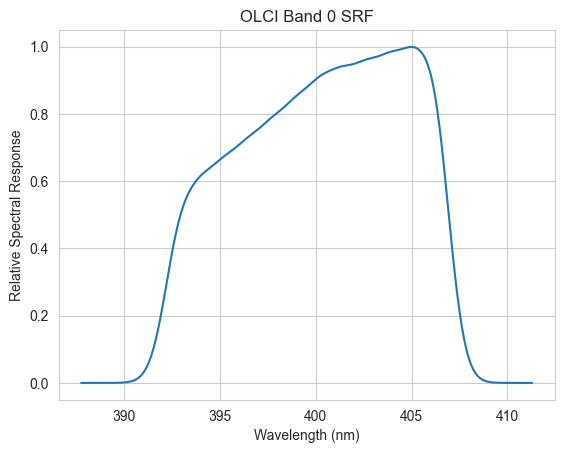

In [25]:

srf = olci_a_SRF['mean_spectral_response_function']
srf_wl = olci_a_SRF['mean_spectral_response_function_wavelength']

band_index = 0
plt.plot(srf_wl.isel(band_number=band_index), srf.isel(band_number=band_index))
plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative Spectral Response")
plt.title(f"OLCI Band {band_index} SRF")
plt.show()

In [26]:
print(srf.isel(band_number=0).values)

[5.66829463e-08 1.09052444e-07 2.06901433e-07 3.87126704e-07
 7.14368412e-07 1.30014712e-06 2.33394053e-06 4.13280168e-06
 7.21929337e-06 1.24417938e-05 2.11574061e-05 3.55052871e-05
 5.88088296e-05 9.61586920e-05 1.55243048e-04 2.47511256e-04
 3.89781635e-04 6.06408692e-04 9.32143885e-04 1.41583977e-03
 2.12513190e-03 3.15385708e-03 4.63076774e-03 6.72416762e-03
 9.65162832e-03 1.36865517e-02 1.91619378e-02 2.64574811e-02
 3.59929465e-02 4.82134707e-02 6.35525584e-02 8.23923796e-02
 1.04987785e-01 1.31431028e-01 1.61599621e-01 1.95118427e-01
 2.31351480e-01 2.69432396e-01 3.08325797e-01 3.46918315e-01
 3.84120822e-01 4.18991297e-01 4.50815767e-01 4.79178071e-01
 5.03950715e-01 5.25283098e-01 5.43521702e-01 5.59119046e-01
 5.72537899e-01 5.84176898e-01 5.94349802e-01 6.03286028e-01
 6.11147285e-01 6.18084192e-01 6.24272168e-01 6.29925132e-01
 6.35277390e-01 6.40544057e-01 6.45882249e-01 6.51371419e-01
 6.56994700e-01 6.62655175e-01 6.68230891e-01 6.73625171e-01
 6.78804457e-01 6.838107

In [28]:
import numpy as np

target_wavelengths = [400, 412, 443, 490, 510, 555, 560, 620, 665, 670, 674, 681, 709]

centre_wl = olci_a_SRF['srf_centre_wavelength'].values  # shape (21,)

band_lookup = {}
for target in target_wavelengths:
    idx = np.argmin(np.abs(centre_wl - target))
    band_lookup[target] = idx
    print(f"Target {target} nm -> band_number {idx} (actual centre: {centre_wl[idx]:.2f} nm)")

Target 400 nm -> band_number 0 (actual centre: 400.30 nm)
Target 412 nm -> band_number 1 (actual centre: 411.85 nm)
Target 443 nm -> band_number 2 (actual centre: 442.96 nm)
Target 490 nm -> band_number 3 (actual centre: 490.49 nm)
Target 510 nm -> band_number 4 (actual centre: 510.47 nm)
Target 555 nm -> band_number 5 (actual centre: 560.45 nm)
Target 560 nm -> band_number 5 (actual centre: 560.45 nm)
Target 620 nm -> band_number 6 (actual centre: 620.41 nm)
Target 665 nm -> band_number 7 (actual centre: 665.27 nm)
Target 670 nm -> band_number 8 (actual centre: 674.03 nm)
Target 674 nm -> band_number 8 (actual centre: 674.03 nm)
Target 681 nm -> band_number 9 (actual centre: 681.57 nm)
Target 709 nm -> band_number 10 (actual centre: 709.11 nm)


In [29]:
import xarray as xr
import numpy as np

ds_a = xr.open_dataset("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/SRF_Sentinel/S3A_OL_SRF_20160713_mean_rsr.nc4")
ds_b = xr.open_dataset("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/SRF_Sentinel/S3B_OL_SRF_0_20180109_mean_rsr.nc4")

centre_wl_a = ds_a['srf_centre_wavelength'].values
centre_wl_b = ds_b['srf_centre_wavelength'].values

target_wavelengths = [400, 412, 443, 490, 510, 555, 560, 620, 665, 670, 674, 681, 709]

for target in target_wavelengths:
    idx_a = np.argmin(np.abs(centre_wl_a - target))
    idx_b = np.argmin(np.abs(centre_wl_b - target))
    diff_a = abs(centre_wl_a[idx_a] - target)
    diff_b = abs(centre_wl_b[idx_b] - target)
    print(f"Target {target} nm | OLCI-A: band {idx_a} ({centre_wl_a[idx_a]:.2f} nm, diff {diff_a:.2f}) "
          f"| OLCI-B: band {idx_b} ({centre_wl_b[idx_b]:.2f} nm, diff {diff_b:.2f})")

Target 400 nm | OLCI-A: band 0 (400.30 nm, diff 0.30) | OLCI-B: band 0 (400.59 nm, diff 0.59)
Target 412 nm | OLCI-A: band 1 (411.85 nm, diff 0.15) | OLCI-B: band 1 (411.95 nm, diff 0.05)
Target 443 nm | OLCI-A: band 2 (442.96 nm, diff 0.04) | OLCI-B: band 2 (442.99 nm, diff 0.01)
Target 490 nm | OLCI-A: band 3 (490.49 nm, diff 0.49) | OLCI-B: band 3 (490.40 nm, diff 0.40)
Target 510 nm | OLCI-A: band 4 (510.47 nm, diff 0.47) | OLCI-B: band 4 (510.40 nm, diff 0.40)
Target 555 nm | OLCI-A: band 5 (560.45 nm, diff 5.45) | OLCI-B: band 5 (560.37 nm, diff 5.37)
Target 560 nm | OLCI-A: band 5 (560.45 nm, diff 0.45) | OLCI-B: band 5 (560.37 nm, diff 0.37)
Target 620 nm | OLCI-A: band 6 (620.41 nm, diff 0.41) | OLCI-B: band 6 (620.28 nm, diff 0.28)
Target 665 nm | OLCI-A: band 7 (665.27 nm, diff 0.27) | OLCI-B: band 7 (665.13 nm, diff 0.13)
Target 670 nm | OLCI-A: band 8 (674.03 nm, diff 4.03) | OLCI-B: band 8 (673.87 nm, diff 3.87)
Target 674 nm | OLCI-A: band 8 (674.03 nm, diff 0.03) | OLCI

In [30]:
nominal_wl_a = ds_a['nominal_centre_wavelength'].values
nominal_wl_b = ds_b['nominal_centre_wavelength'].values

for target in target_wavelengths:
    idx_a = np.argmin(np.abs(nominal_wl_a - target))
    idx_b = np.argmin(np.abs(nominal_wl_b - target))
    print(f"Target {target} nm | OLCI-A nominal: {nominal_wl_a[idx_a]:.2f} nm "
          f"| OLCI-B nominal: {nominal_wl_b[idx_b]:.2f} nm")

Target 400 nm | OLCI-A nominal: 400.00 nm | OLCI-B nominal: 400.00 nm
Target 412 nm | OLCI-A nominal: 412.50 nm | OLCI-B nominal: 412.50 nm
Target 443 nm | OLCI-A nominal: 442.50 nm | OLCI-B nominal: 442.50 nm
Target 490 nm | OLCI-A nominal: 490.00 nm | OLCI-B nominal: 490.00 nm
Target 510 nm | OLCI-A nominal: 510.00 nm | OLCI-B nominal: 510.00 nm
Target 555 nm | OLCI-A nominal: 560.00 nm | OLCI-B nominal: 560.00 nm
Target 560 nm | OLCI-A nominal: 560.00 nm | OLCI-B nominal: 560.00 nm
Target 620 nm | OLCI-A nominal: 620.00 nm | OLCI-B nominal: 620.00 nm
Target 665 nm | OLCI-A nominal: 665.00 nm | OLCI-B nominal: 665.00 nm
Target 670 nm | OLCI-A nominal: 673.75 nm | OLCI-B nominal: 673.75 nm
Target 674 nm | OLCI-A nominal: 673.75 nm | OLCI-B nominal: 673.75 nm
Target 681 nm | OLCI-A nominal: 681.25 nm | OLCI-B nominal: 681.25 nm
Target 709 nm | OLCI-A nominal: 708.75 nm | OLCI-B nominal: 708.75 nm


## Convolve Data

In [53]:
import xarray as xr
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def apply_olci_srf(in_situ_df, srf_nc_path):
    """
    Convolves hyperspectral in-situ Rrs spectra with OLCI SRFs.

    Parameters:
    -----------
    in_situ_df : pd.DataFrame
        DataFrame output from all_site_means_SRF containing site metadata and
        hyperspectral Rrs columns (named numerically or as float strings, e.g. '400.0' or 400.0).
    srf_nc_path : str
        Path to the OLCI S3A or S3B SRF NetCDF file.

    Returns:
    --------
    pd.DataFrame
        DataFrame with original metadata and convolved OLCI band Rrs columns.
    """
    # 1. Load SRF NetCDF File
    ds_srf = xr.open_dataset(srf_nc_path)
    srf_weights = ds_srf['mean_spectral_response_function'].values  # Shape: (21, 200)
    srf_lambdas = ds_srf['mean_spectral_response_function_wavelength'].values  # Shape: (21, 200)
    band_centers = ds_srf['nominal_centre_wavelength'].values  # Shape: (21,)

    # 2. Identify in-situ hyperspectral wavelength columns
    # Assumes wavelength column names are numeric or convertible to float (e.g., '400', '401.5')
    insitu_wave_cols = []
    for col in in_situ_df.columns:
        try:
            float(col)
            insitu_wave_cols.append(col)
        except ValueError:
            continue

    insitu_wavelengths = np.array([float(c) for c in insitu_wave_cols])

    # Sort wavelengths just in case
    sort_idx = np.argsort(insitu_wavelengths)
    insitu_wavelengths = insitu_wavelengths[sort_idx]
    sorted_wave_cols = [insitu_wave_cols[i] for i in sort_idx]

    # Preserve non-hyperspectral metadata columns
    metadata_cols = [col for col in in_situ_df.columns if col not in insitu_wave_cols]
    result_df = in_situ_df[metadata_cols].copy()

    # 3. Convolve each row (station observation) with the 21 OLCI SRF bands
    num_bands = srf_weights.shape[0]
    convolved_rrs = np.zeros((len(in_situ_df), num_bands))

    for idx, (_, row) in enumerate(in_situ_df.iterrows()):
        rrs_hyperspectral = row[sorted_wave_cols].values.astype(float)

        # Build 1D interpolation function for the in-situ spectrum
        interp_rrs = interp1d(
            insitu_wavelengths,
            rrs_hyperspectral,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )

        for b in range(num_bands):
            band_srf_wl = srf_lambdas[b, :]
            band_srf_w = srf_weights[b, :]

            # Mask valid (non-zero) SRF weights
            valid_srf = band_srf_w > 0
            if not np.any(valid_srf):
                convolved_rrs[idx, b] = np.nan
                continue

            wl_subset = band_srf_wl[valid_srf]
            w_subset = band_srf_w[valid_srf]

            # Interpolate in-situ Rrs to the exact SRF wavelength grid points
            rrs_at_srf_wl = interp_rrs(wl_subset)

            # Mask out any NaNs if in-situ spectrum didn't cover full SRF wavelength range
            valid_mask = ~np.isnan(rrs_at_srf_wl)
            if np.sum(valid_mask) < (len(wl_subset) * 0.8):  # Ensure >=80% overlap
                convolved_rrs[idx, b] = np.nan
            else:
                # Weighted trapezoidal integration: integral(Rrs * SRF) / integral(SRF)
                num = np.trapezoid(rrs_at_srf_wl[valid_mask] * w_subset[valid_mask], x=wl_subset[valid_mask])
                den = np.trapezoid(w_subset[valid_mask], x=wl_subset[valid_mask])
                convolved_rrs[idx, b] = num / den if den != 0 else np.nan

    # 4. Attach convolved band columns named by nominal OLCI center wavelength
    for b in range(num_bands):
        col_name = f"Rrs_srf_{band_centers[b]:.1f}"
        result_df[col_name] = convolved_rrs[:, b]

    return result_df


In [54]:



# Example Usage:
# Process in-situ data separately for S3A and S3B match-ups
srf_s3a_path = "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/SRF_Sentinel/S3A_OL_SRF_20160713_mean_rsr.nc4"
srf_s3b_path = "C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/SRF_Sentinel/S3B_OL_SRF_0_20180109_mean_rsr.nc4"

all_site_means_SRF_S3A = apply_olci_srf(all_site_means_SRF, srf_s3a_path)
all_site_means_SRF_S3B = apply_olci_srf(all_site_means_SRF, srf_s3b_path)

In [55]:
all_site_means_SRF_S3A

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,Rrs_srf_400.0,Rrs_srf_412.5,Rrs_srf_442.5,Rrs_srf_490.0,...,Rrs_srf_753.8,Rrs_srf_761.2,Rrs_srf_764.4,Rrs_srf_767.5,Rrs_srf_778.8,Rrs_srf_865.0,Rrs_srf_885.0,Rrs_srf_900.0,Rrs_srf_940.0,Rrs_srf_1020.0
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,0.000497,0.000562,0.000781,0.001509,...,0.000077,0.000101,0.000095,0.000077,0.000059,0.000006,0.000003,0.000021,0.000194,NaN
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,0.000533,0.000610,0.000884,0.001660,...,0.000083,0.000106,0.000100,0.000082,0.000065,0.000007,0.000003,0.000019,0.000186,NaN
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,0.000322,0.000423,0.000743,0.001453,...,0.000070,0.000092,0.000087,0.000071,0.000056,0.000006,0.000002,0.000017,0.000162,NaN
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,0.000273,0.000400,0.000766,0.001465,...,0.000067,0.000108,0.000101,0.000075,0.000053,0.000010,0.000008,0.000029,0.000204,NaN
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,0.000322,0.000385,0.000520,0.000796,...,0.000131,0.000180,0.000170,0.000137,0.000112,0.000019,0.000007,0.000019,0.000165,NaN
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,0.000163,0.000268,0.000557,0.001154,...,0.000081,0.000110,0.000105,0.000086,0.000071,0.000013,0.000005,0.000008,0.000114,NaN
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,0.000404,0.000529,0.000875,0.001574,...,0.000061,0.000097,0.000092,0.000069,0.000051,0.000014,0.000010,0.000015,0.000143,NaN
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,0.000934,0.001044,0.001295,0.001798,...,0.000102,0.000235,0.000216,0.000137,0.000068,0.000018,0.000017,0.000079,0.000449,NaN
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,0.000776,0.000860,0.001040,0.001423,...,0.000083,0.000183,0.000165,0.000105,0.000063,0.000030,0.000026,0.000038,0.000247,NaN
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,0.000870,0.000984,0.001255,0.001860,...,0.000086,0.000188,0.000166,0.000104,0.000060,0.000019,0.000016,0.000041,0.000308,NaN


In [57]:
all_site_means_SRF

,Site,Date,Timestamp_Start,Timestamp_End,Latitude,Longitude,320,322,324,326,...,932,934,936,938,940,942,944,946,948,950
0,ISO-01,2026-04-28,2026-04-28 11:28:00,2026-04-28 11:38:00,53.263103,-9.039540,-0.005708,-0.005151,-0.004596,-0.004042,...,0.000139,1.704278e-04,0.000196,0.000213,0.000221,0.000223,0.000224,0.000224,0.000225,0.000226
1,ISO-02,2026-04-28,2026-04-28 11:43:00,2026-04-28 11:50:00,53.260653,-9.037058,-0.005581,-0.005033,-0.004488,-0.003945,...,0.000133,1.639706e-04,0.000189,0.000206,0.000214,0.000216,0.000215,0.000214,0.000213,0.000212
2,ISO-03,2026-04-28,2026-04-28 12:02:00,2026-04-28 12:09:00,53.250777,-9.036935,-0.005823,-0.005282,-0.004743,-0.004205,...,0.000116,1.431176e-04,0.000165,0.000179,0.000186,0.000187,0.000187,0.000187,0.000186,0.000186
3,ISO-04,2026-04-28,2026-04-28 12:18:00,2026-04-28 12:26:00,53.244920,-9.041622,-0.006524,-0.005931,-0.005342,-0.004754,...,0.000146,1.797586e-04,0.000208,0.000227,0.000236,0.000237,0.000235,0.000234,0.000232,0.000230
4,ISO-08A,2026-04-28,2026-04-28 15:18:00,2026-04-28 15:25:00,53.141730,-8.936175,-0.006117,-0.005541,-0.004969,-0.004397,...,0.000112,1.445868e-04,0.000171,0.000189,0.000195,0.000194,0.000192,0.000189,0.000187,0.000185
5,ISO-08B,2026-04-28,2026-04-28 15:41:00,2026-04-28 15:47:00,53.158338,-8.948395,-0.006501,-0.005923,-0.005347,-0.004772,...,0.000074,9.643564e-05,0.000116,0.000129,0.000134,0.000135,0.000135,0.000134,0.000134,0.000134
6,ISO-09,2026-04-28,2026-04-28 15:58:00,2026-04-28 16:02:00,53.167728,-8.955467,-0.006526,-0.005954,-0.005383,-0.004811,...,0.000097,1.228571e-04,0.000146,0.000163,0.000170,0.000169,0.000167,0.000165,0.000164,0.000162
7,ISO-10,2026-04-28,2026-04-28 16:13:00,2026-04-28 16:15:00,53.175897,-8.962217,-0.007164,-0.006481,-0.005800,-0.005120,...,0.000311,3.889189e-04,0.000458,0.000506,0.000526,0.000525,0.000519,0.000514,0.000510,0.000505
8,ISO-11,2026-04-28,2026-04-28 16:24:00,2026-04-28 16:34:00,53.180213,-8.970387,-0.006365,-0.005768,-0.005169,-0.004569,...,0.000164,2.134333e-04,0.000256,0.000285,0.000296,0.000293,0.000287,0.000282,0.000277,0.000272
9,ISO-12,2026-04-28,2026-04-28 16:43:00,2026-04-28 16:48:00,53.179393,-8.979265,-0.006719,-0.006101,-0.005481,-0.004858,...,0.000210,2.698851e-04,0.000319,0.000351,0.000364,0.000362,0.000356,0.000351,0.000347,0.000342


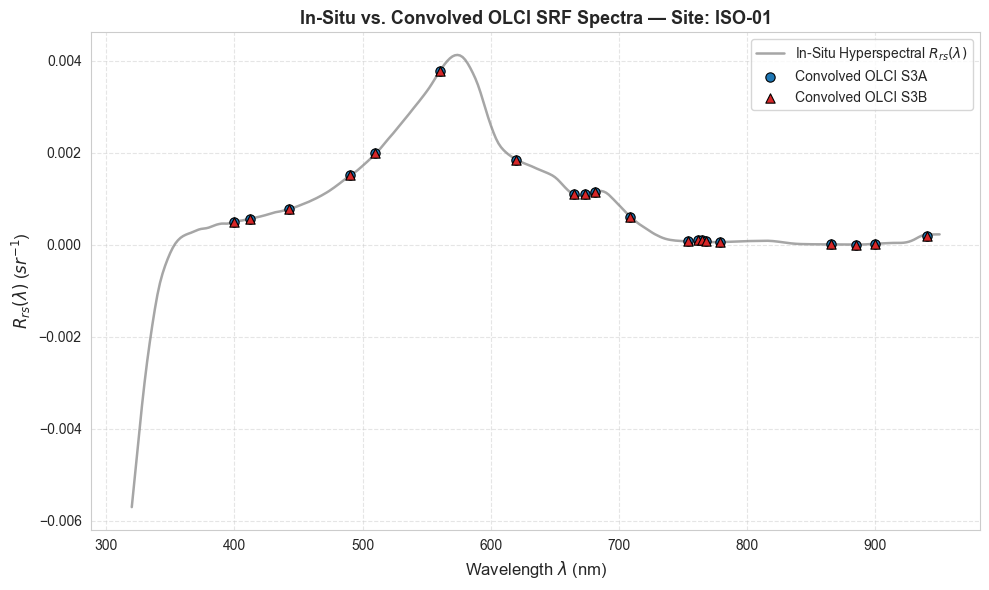

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_srf_comparison(df_orig, df_s3a, df_s3b, site_id, site_col='Site'):
    """
    Plots original hyperspectral Rrs line with convolved S3A and S3B band markers.

    Parameters:
    -----------
    df_orig : pd.DataFrame
        Original all_site_means_SRF dataframe containing hyperspectral Rrs.
    df_s3a : pd.DataFrame
        Convolved S3A dataframe output from apply_olci_srf.
    df_s3b : pd.DataFrame
        Convolved S3B dataframe output from apply_olci_srf.
    site_id : str or int
        The site identifier to plot.
    site_col : str
        Column name used for site identification (e.g., 'site', 'station', 'site_id').
    """
    # 1. Filter rows for the requested site
    row_orig = df_orig[df_orig[site_col] == site_id].iloc[0]
    row_s3a = df_s3a[df_s3a[site_col] == site_id].iloc[0]
    row_s3b = df_s3b[df_s3b[site_col] == site_id].iloc[0]

    # 2. Extract original hyperspectral wavelengths and Rrs
    orig_wave_cols = []
    for col in df_orig.columns:
        try:
            float(col)
            orig_wave_cols.append(col)
        except ValueError:
            continue

    wl_orig = np.array([float(c) for c in orig_wave_cols])
    sort_idx = np.argsort(wl_orig)
    wl_orig = wl_orig[sort_idx]
    rrs_orig = row_orig[[orig_wave_cols[i] for i in sort_idx]].values.astype(float)

    # 3. Extract convolved S3A and S3B band centers and Rrs values
    s3a_cols = [c for c in df_s3a.columns if c.startswith('Rrs_srf_')]
    wl_s3a = np.array([float(c.replace('Rrs_srf_', '')) for c in s3a_cols])
    rrs_s3a = row_s3a[s3a_cols].values.astype(float)

    s3b_cols = [c for c in df_s3b.columns if c.startswith('Rrs_srf_')]
    wl_s3b = np.array([float(c.replace('Rrs_srf_', '')) for c in s3b_cols])
    rrs_s3b = row_s3b[s3b_cols].values.astype(float)

    # 4. Generate the comparison plot
    plt.figure(figsize=(10, 6))

    # Background line: Original Hyperspectral In-Situ Spectrum
    plt.plot(
        wl_orig,
        rrs_orig,
        color='grey',
        linestyle='-',
        linewidth=1.8,
        alpha=0.7,
        label=r'In-Situ Hyperspectral $R_{rs}(\lambda)$'
    )

    # Overlaid markers: Convolved Sentinel-3A OLCI
    plt.scatter(
        wl_s3a,
        rrs_s3a,
        color='#1f77b4',  # Blue
        marker='o',
        s=45,
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
        label='Convolved OLCI S3A'
    )

    # Overlaid markers: Convolved Sentinel-3B OLCI
    plt.scatter(
        wl_s3b,
        rrs_s3b,
        color='#d62728',  # Red
        marker='^',
        s=45,
        edgecolor='black',
        linewidth=0.8,
        zorder=4,
        label='Convolved OLCI S3B'
    )

    # Formatting and labels
    plt.xlabel(r'Wavelength $\lambda$ (nm)', fontsize=12)
    plt.ylabel(r'$R_{rs}(\lambda)$ ($sr^{-1}$)', fontsize=12)
    plt.title(f'In-Situ vs. Convolved OLCI SRF Spectra — Site: {site_id}', fontsize=13, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, loc='best')
    plt.tight_layout()

    plt.show()


# Example Usage:
# Replace 'site_name_or_id' with your actual site label and column name
plot_srf_comparison(
    df_orig=all_site_means_SRF,
    df_s3a=all_site_means_SRF_S3A,
    df_s3b=all_site_means_SRF_S3B,
    site_id='ISO-01',
    site_col='Site'
)

In [1]:
all_site_means_SRF.describe()

NameError: name 'all_site_means_SRF' is not defined

In [63]:
all_site_means_SRF_S3A.to_csv("convolved_insitu_hyperspectral_S3A.csv")
all_site_means_SRF_S3B.to_csv("convolved_insitu_hyperspectral_S3B.csv")
all_site_means_SRF.to_csv("insitu_hyperspectral_withtimestamps.csv")